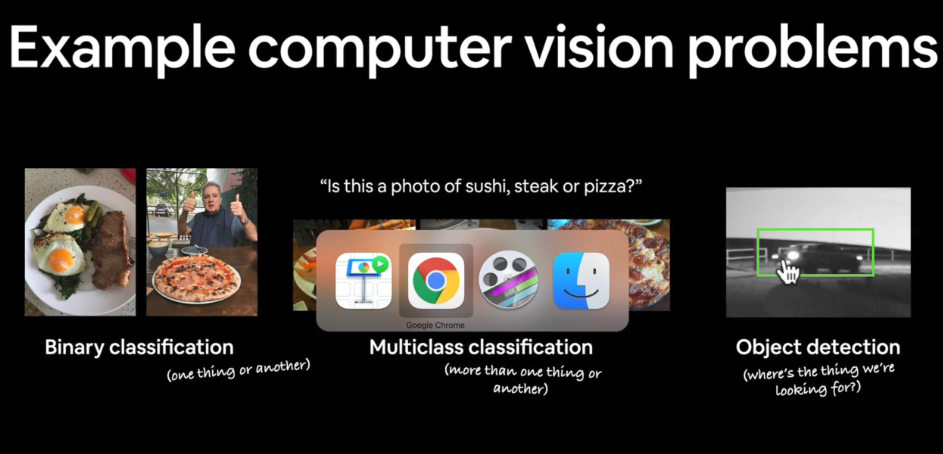

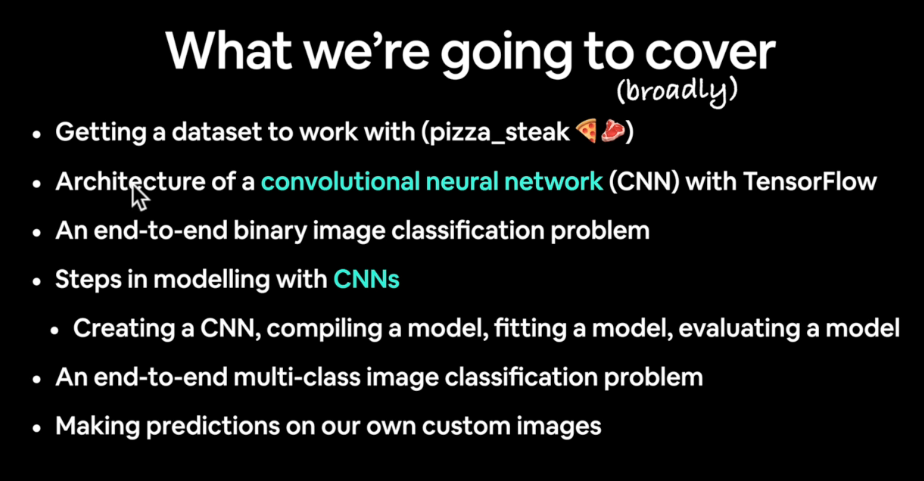

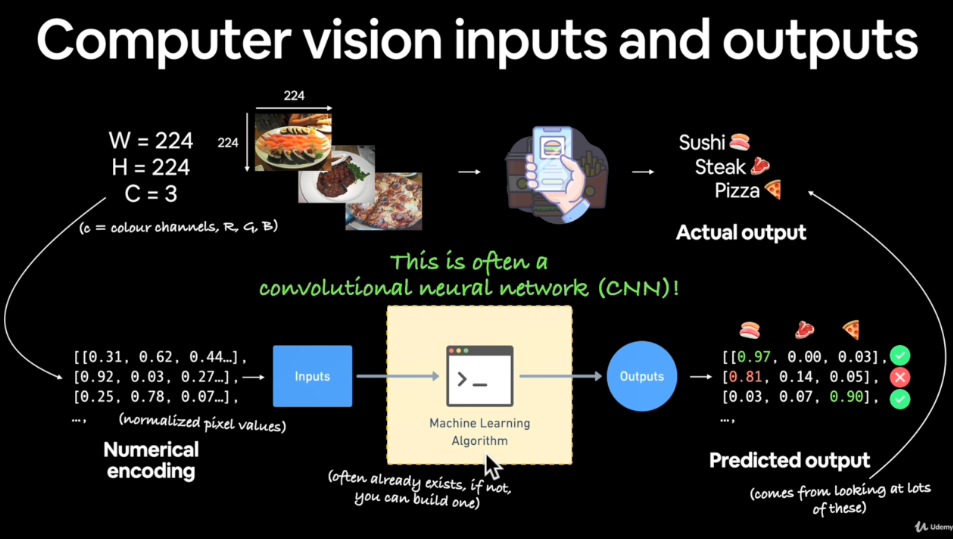

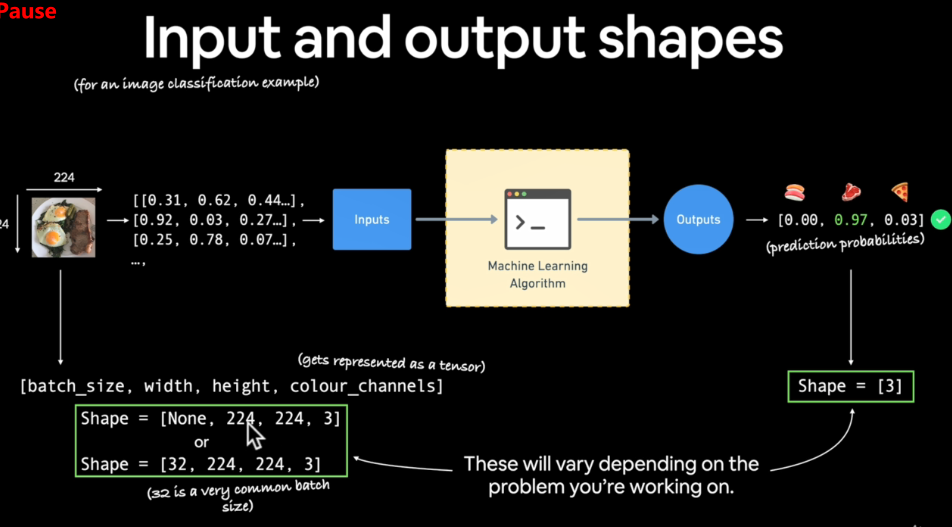

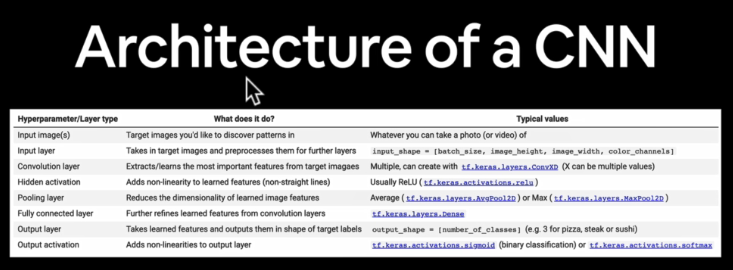

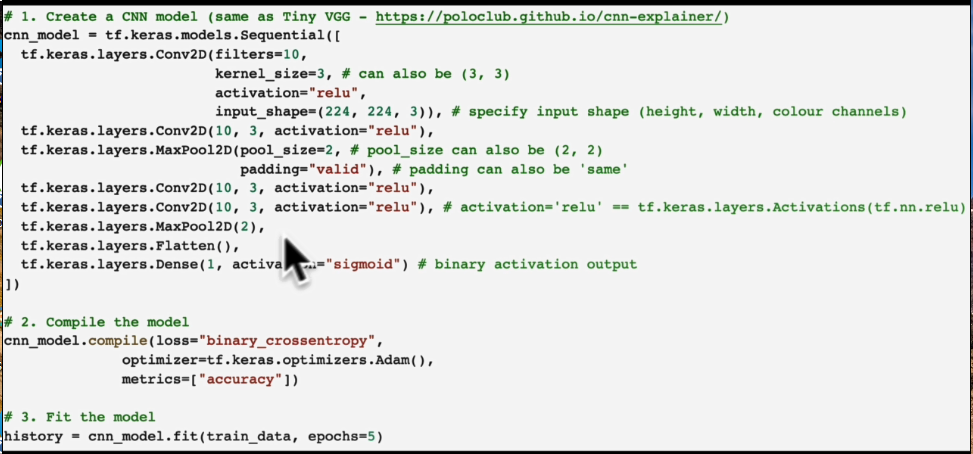

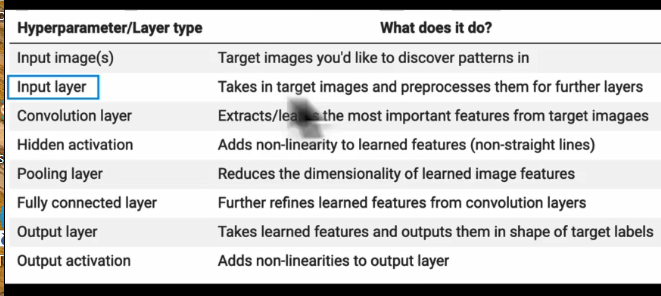

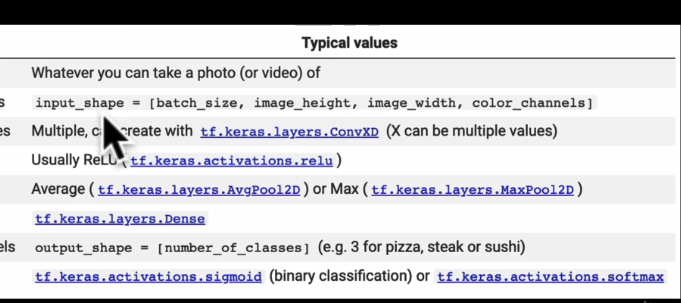

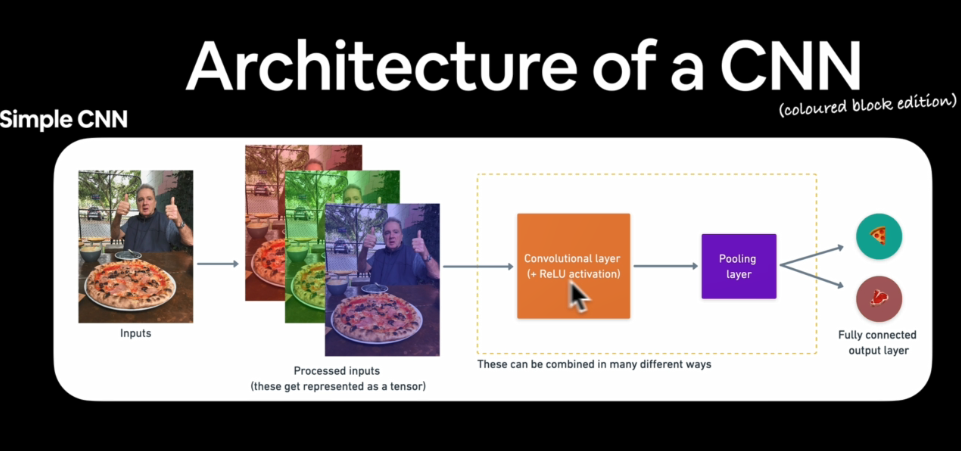

When you stack many Convolutional layer and pooling layer

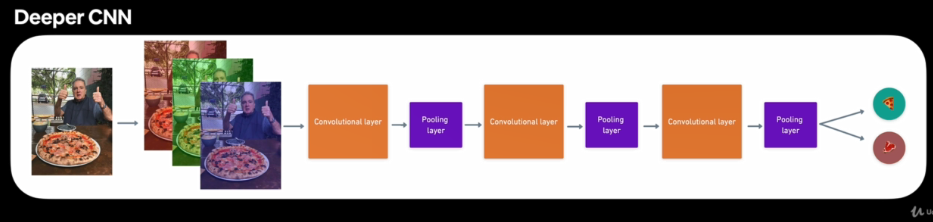

<h1 style="color:red">lec 003:-Downloading an image dataset for our first Food Vision model.mp4</h1>

# Introduction to Convolutional Neural Networks and Computer Vision with TensorFlow

Computer vision is the practice of writing algorithms which can discover patterns in visual data. Such as the camera of a self-driving car recognizing the car in front.

## Get the data

The images we're working with are from the Food101 dataset (101 different classes of food): https://www.kaggle.com/datasets/dansbecker/food-101

However we've modified it to only use two classes (pizza & steak) using the image data modification notebook: https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/image_data_modification.ipynb

> **Note:** We start with a smaller dataset so we can experiment quickly and figure what works (or better yet what doesn't work) before scaling up.


In [81]:
import zipfile

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# Unzip
zip_ref = zipfile.ZipFile("pizza_steak.zip")
zip_ref.extractall()
zip_ref.close()

--2026-01-12 17:07:33--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.141.207, 142.250.101.207, 142.251.2.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.141.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip.1’

pizza_steak.zip.1   100%[===================>] 104.47M   230MB/s    in 0.5s    

2026-01-12 17:07:33 (230 MB/s) - ‘pizza_steak.zip.1’ saved [109540975/109540975]



<h1 style="color:red">lec 004:-Becoming One With Data.mp4</h1>

## Inspect the data (become one with it)

A very crucial step at the beginning of any machie learning project us becoming one with the data.

And for a computer vision project... this usually means visualizing many samples of your data.

In [82]:
!ls pizza_steak/

test  train


In [83]:
!ls pizza_steak/train/

pizza  steak


In [84]:
!ls pizza_steak/train/steak

1000205.jpg  1647351.jpg  2238681.jpg  2824680.jpg  3375959.jpg  417368.jpg
100135.jpg   1650002.jpg  2238802.jpg  2825100.jpg  3381560.jpg  4176.jpg
101312.jpg   165639.jpg   2254705.jpg  2826987.jpg  3382936.jpg  42125.jpg
1021458.jpg  1658186.jpg  225990.jpg   2832499.jpg  3386119.jpg  421476.jpg
1032846.jpg  1658443.jpg  2260231.jpg  2832960.jpg  3388717.jpg  421561.jpg
10380.jpg    165964.jpg   2268692.jpg  285045.jpg   3389138.jpg  438871.jpg
1049459.jpg  167069.jpg   2271133.jpg  285147.jpg   3393547.jpg  43924.jpg
1053665.jpg  1675632.jpg  227576.jpg   2855315.jpg  3393688.jpg  440188.jpg
1068516.jpg  1678108.jpg  2283057.jpg  2856066.jpg  3396589.jpg  442757.jpg
1068975.jpg  168006.jpg   2286639.jpg  2859933.jpg  339891.jpg	 443210.jpg
1081258.jpg  1682496.jpg  2287136.jpg  286219.jpg   3417789.jpg  444064.jpg
1090122.jpg  1684438.jpg  2291292.jpg  2862562.jpg  3425047.jpg  444709.jpg
1093966.jpg  168775.jpg   229323.jpg   2865730.jpg  3434983.jpg  447557.jpg
1098844.jpg  1697

In [85]:
import os

# Walk through pizza_steak directory and list number of files
for dirpath,dirnames,filenames in os.walk("pizza_steak"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'pizza_steak'.
There are 2 directories and 0 images in 'pizza_steak/test'.
There are 0 directories and 250 images in 'pizza_steak/test/steak'.
There are 0 directories and 250 images in 'pizza_steak/test/pizza'.
There are 2 directories and 0 images in 'pizza_steak/train'.
There are 0 directories and 750 images in 'pizza_steak/train/steak'.
There are 0 directories and 750 images in 'pizza_steak/train/pizza'.


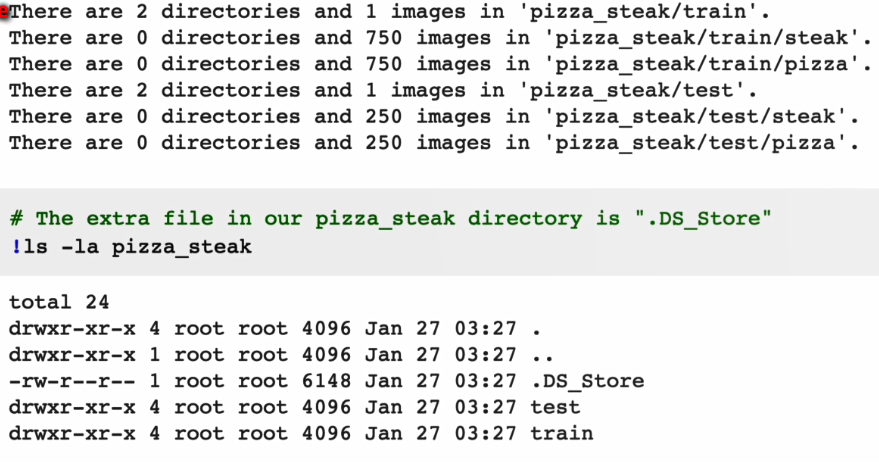

<h1 style="color:red">lec 005:-Becoming One With Data Part 2.mp4</h1>

In [86]:
# Another way to find out how many images are in a file
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))

num_steak_images_train

750

To visualize our images, first let's get the class names programmatically

In [87]:
# Get the classnames programmatically
import pathlib
import numpy as np
data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted([item.name for item in data_dir.glob("*")])) # Created a list of class_names from the subdirectories
print(class_names)

['pizza' 'steak']


In [88]:
import random
random_image = random.sample(os.listdir("pizza_steak/train/pizza"), 1)
print(random_image[0])
print(random_image)

2697971.jpg
['2697971.jpg']


In [89]:
# Let's visualize our images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
  # Setup the target directory (we'll view images from here)
  target_folder = target_dir+"/"+target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  # Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder+"/"+random_image[0]) # random_image[0] because random.sample gives list and we want only one element
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off");


  print(random_image)
  print(f"Image shape: {img.shape}")

  return img


['3913912.jpg']
Image shape: (512, 384, 3)


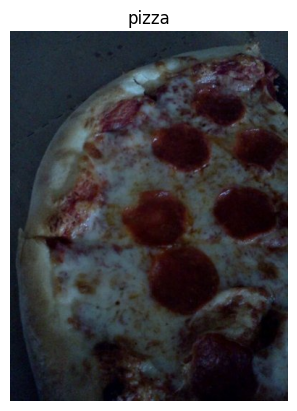

In [90]:
# View a random image from the training dataset
img = view_random_image(target_dir="pizza_steak/train",
                        target_class="pizza")

array([[[33, 44, 50],
        [30, 41, 47],
        [30, 41, 47],
        ...,
        [37, 47, 56],
        [34, 47, 55],
        [35, 48, 56]],

       [[31, 41, 50],
        [30, 41, 47],
        [31, 41, 50],
        ...,
        [39, 49, 58],
        [37, 50, 58],
        [38, 51, 59]],

       [[30, 40, 50],
        [30, 40, 49],
        [32, 42, 52],
        ...,
        [38, 51, 59],
        [37, 50, 58],
        [38, 51, 59]],

       ...,

       [[10, 15, 19],
        [11, 16, 20],
        [11, 16, 22],
        ...,
        [19, 13, 17],
        [18, 12, 16],
        [25, 19, 23]],

       [[10, 15, 18],
        [11, 16, 20],
        [10, 17, 23],
        ...,
        [22, 16, 20],
        [21, 12, 17],
        [26, 17, 22]],

       [[11, 16, 19],
        [12, 17, 20],
        [11, 18, 24],
        ...,
        [25, 19, 23],
        [22, 13, 18],
        [25, 16, 21]]], dtype=uint8)
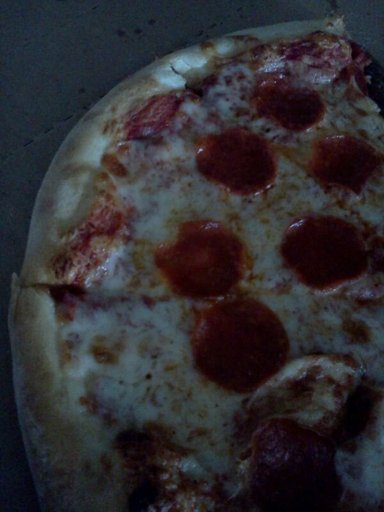

In [91]:
img

<h1 style="color:red">lec 006:-Becoming One With Data Part 3.mp4</h1>

In [92]:
# The images we've imported and plotted are actually giant arrays/tensors of different pixel values
import tensorflow as tf
tf.constant(img)

<tf.Tensor: shape=(512, 384, 3), dtype=uint8, numpy=
array([[[33, 44, 50],
        [30, 41, 47],
        [30, 41, 47],
        ...,
        [37, 47, 56],
        [34, 47, 55],
        [35, 48, 56]],

       [[31, 41, 50],
        [30, 41, 47],
        [31, 41, 50],
        ...,
        [39, 49, 58],
        [37, 50, 58],
        [38, 51, 59]],

       [[30, 40, 50],
        [30, 40, 49],
        [32, 42, 52],
        ...,
        [38, 51, 59],
        [37, 50, 58],
        [38, 51, 59]],

       ...,

       [[10, 15, 19],
        [11, 16, 20],
        [11, 16, 22],
        ...,
        [19, 13, 17],
        [18, 12, 16],
        [25, 19, 23]],

       [[10, 15, 18],
        [11, 16, 20],
        [10, 17, 23],
        ...,
        [22, 16, 20],
        [21, 12, 17],
        [26, 17, 22]],

       [[11, 16, 19],
        [12, 17, 20],
        [11, 18, 24],
        ...,
        [25, 19, 23],
        [22, 13, 18],
        [25, 16, 21]]], dtype=uint8)>

In [93]:
# View the image shape
img.shape # Returns width,height,color channels

(512, 384, 3)

> **Note:** As we've discussed before, many machine learning models, including neural networks prefer the values they work with to be between 0 and 1. knowing this, one of the most common preprocessing steps for working with images is to **scale**(also referred to as **normalize**) their pixel values by dividing the image arrays by 255. (since 255 and 0 are the maximum and minimum pixel values respectively).

In [94]:
# Get all the pixel values between 0 & 1
img/255.0

array([[[0.12941176, 0.17254902, 0.19607843],
        [0.11764706, 0.16078431, 0.18431373],
        [0.11764706, 0.16078431, 0.18431373],
        ...,
        [0.14509804, 0.18431373, 0.21960784],
        [0.13333333, 0.18431373, 0.21568627],
        [0.1372549 , 0.18823529, 0.21960784]],

       [[0.12156863, 0.16078431, 0.19607843],
        [0.11764706, 0.16078431, 0.18431373],
        [0.12156863, 0.16078431, 0.19607843],
        ...,
        [0.15294118, 0.19215686, 0.22745098],
        [0.14509804, 0.19607843, 0.22745098],
        [0.14901961, 0.2       , 0.23137255]],

       [[0.11764706, 0.15686275, 0.19607843],
        [0.11764706, 0.15686275, 0.19215686],
        [0.1254902 , 0.16470588, 0.20392157],
        ...,
        [0.14901961, 0.2       , 0.23137255],
        [0.14509804, 0.19607843, 0.22745098],
        [0.14901961, 0.2       , 0.23137255]],

       ...,

       [[0.03921569, 0.05882353, 0.0745098 ],
        [0.04313725, 0.0627451 , 0.07843137],
        [0.04313725, 0

<h1 style="color:red">lec 007:-Building an end to end CNN Model.mp4</h1>

This line defines a **2D convolution layer** in TensorFlow/Keras, typically used for **image data**.

Breakdown, parameter by parameter:

**`tf.keras.layers.Conv2D(...)`**
Creates a convolutional layer that slides small filters over an image to extract spatial features (edges, textures, patterns).

**`filters=10`**
Number of convolution kernels (feature maps).
Output will have **10 channels**.
More filters → more types of features learned.

**`kernel_size=3`**
Size of each filter is **3×3**.
This kernel looks at a 3×3 pixel neighborhood at a time.

**`activation="relu"`**
Applies ReLU after convolution:
[
\text{ReLU}(x) = \max(0, x)
]
Introduces non-linearity and prevents vanishing gradients.

**`input_shape=(224, 224, 3)`**
Shape of **one input image**:

* 224 height
* 224 width
* 3 color channels (RGB)

Used **only in the first layer** of a model so Keras knows input dimensions.

---

### What happens internally

1. 10 different 3×3×3 filters slide over the image
2. Dot product + bias at each position
3. ReLU applied
4. Output shape (default settings):
   [
   (222, 222, 10)
   ]
   Reason: no padding → size reduces by `kernel_size - 1`.

---

### Key notes

* Default `strides=(1,1)`
* Default `padding="valid"`
* Trainable parameters:
  [
  (3×3×3 + 1) × 10 = 280
  ]

This layer is typically followed by pooling or more Conv2D layers.


This line defines a **2D convolution layer** in TensorFlow/Keras, typically used for **image data**.

Breakdown, parameter by parameter:

**`tf.keras.layers.Conv2D(...)`**
Creates a convolutional layer that slides small filters over an image to extract spatial features (edges, textures, patterns).

**`filters=10`**
Number of convolution kernels (feature maps).
Output will have **10 channels**.
More filters → more types of features learned.

**`kernel_size=3`**
Size of each filter is **3×3**.
This kernel looks at a 3×3 pixel neighborhood at a time.

**`activation="relu"`**
Applies ReLU after convolution:
[
\text{ReLU}(x) = \max(0, x)
]
Introduces non-linearity and prevents vanishing gradients.

**`input_shape=(224, 224, 3)`**
Shape of **one input image**:

* 224 height
* 224 width
* 3 color channels (RGB)

Used **only in the first layer** of a model so Keras knows input dimensions.

---

### What happens internally

1. 10 different 3×3×3 filters slide over the image
2. Dot product + bias at each position
3. ReLU applied
4. Output shape (default settings):
   [
   (222, 222, 10)
   ]
   Reason: no padding → size reduces by `kernel_size - 1`.

---

### Key notes

* Default `strides=(1,1)`
* Default `padding="valid"`
* Trainable parameters:
  [
  (3×3×3 + 1) × 10 = 280
  ]

This layer is typically followed by pooling or more Conv2D layers.


This defines a **2D max-pooling layer**, used to **downsample feature maps**.

---

### `tf.keras.layers.MaxPool2D(...)`

Reduces **spatial dimensions (height & width)** while keeping the **number of channels the same**.

---

### Parameter breakdown

**`pool_size=2`**
Window size is **2 × 2**.
From each 2×2 region, the **maximum value** is selected.

**`padding="valid"`**
No padding is added.
Pooling is applied only where the 2×2 window fully fits inside the feature map.

(Default stride = pool size = 2)

---

### What actually happens

Input feature map (example):

```
8 × 8 × 10
```

After max pooling:

```
4 × 4 × 10
```

Why:

* Height → divided by 2
* Width → divided by 2
* Channels unchanged

---

### Operation example (single channel)

Input:

```
[[1, 3],
 [2, 0]]
```

Output:

```
[3]
```

Only the **largest value survives**.

---

### Why max pooling is used

* Reduces computation
* Reduces overfitting
* Keeps strongest features
* Adds slight translation invariance

---

### Key rules to remember

* Pooling has **no trainable parameters**
* Channels are **never changed**
* Only spatial size shrinks

---

### One-line summary

`MaxPool2D(pool_size=2, padding="valid")` downsamples feature maps by taking the maximum value from each non-overlapping 2×2 region.


## An end-to-end example

Let's build a convolutional neural network to find patterns in our images, more specifically we need a way to:

* Load our images
* Preprocess our images
* Build a CNN to find patterns in our images
* Compile our CNN
* Fit the CNN to our training data


In [95]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# set the seed
tf.random.set_seed(42)

# Preprocess data (get all of the pixel values between 0 & 1, also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup path to our data directories
train_dir = "pizza_steak/train"
test_dir = "pizza_steak/test"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               batch_size = 32,
                                               target_size=(224,224),
                                               class_mode="binary",
                                               seed = 42)
valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode="binary",
                                               seed=42)

# Build a CNN model (same as the Tiny VGG on the CNN explainer website)
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=(3,3),
                           activation="relu",
                           input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2,
                       padding="valid"),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    # tf.keras.layers.Activations(tf.nn.relu),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile our CNN
model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_1 = model_1.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 337ms/step - accuracy: 0.6396 - loss: 0.6329 - val_accuracy: 0.7740 - val_loss: 0.4477
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 257ms/step - accuracy: 0.8160 - loss: 0.4260 - val_accuracy: 0.8600 - val_loss: 0.3445
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - accuracy: 0.8397 - loss: 0.3537 - val_accuracy: 0.8600 - val_loss: 0.3438
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.8588 - loss: 0.3233 - val_accuracy: 0.8760 - val_loss: 0.3022
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 213ms/step - accuracy: 0.9066 - loss: 0.2718 - val_accuracy: 0.8700 - val_loss: 0.3180


> **Note:** If the above cell is taking longer than ~10 seconds per epoch, make sure you're using a GPU by going to Runtime-> Change runtime type -> T4 GPU -> save

**Without GPU:-**

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step

<h1 style="color:red">lec 008:-Using a GPU to run our CNN model 5x faster.mp4</h1>

In [96]:
# Get a model summary
model_1.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

**Practice/exercise:** Go through the CNN explainer website for a minimum of 10-minutes and compare our neural network with theirs:-
[CNN explainer study there](https://poloclub.github.io/cnn-explainer/)

<h1 style="color:red">lec 009:-Trying a non-CNN model on our image data.mp4</h1>

## Using the same model as before

Let's replicate the model we've built in a previous section to see if it works with our image data.

The model we're building is from the TensorFlow playground: https://playground.tensorflow.org

In [97]:
# Set random seed
tf.random.set_seed(42)

# Create a model to replicate the TensorFlow Playground model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224,224,3)),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Compile the model
model_2.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 318ms/step - accuracy: 0.5088 - loss: 0.7000 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.4939 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 236ms/step - accuracy: 0.4962 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.5052 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.4603 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931


<h1 style="color:red">lec 010:-Improving our non-CNN model by adding more layers.mp4</h1>

In [98]:
# Get a summary of model_2
model_2.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │       602,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,806,425 (6.89 MB)

 Trainable params: 602,141 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,204,284 (4.59 MB)

Despite having 20x more parameters than our CNN (model_1), model_2 performs terribly... let's try to improve it.

In [99]:
# Set the random seed
tf.random.set_seed(42)

# Create the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224,224,3)),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])

# Compile the model
model_3.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_3 = model_3.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=valid_data,
                        validation_steps=len(valid_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step - accuracy: 0.5402 - loss: 8.3869 - val_accuracy: 0.7220 - val_loss: 1.2074
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 180ms/step - accuracy: 0.6752 - loss: 1.3052 - val_accuracy: 0.7280 - val_loss: 0.8766
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.7486 - loss: 0.6830 - val_accuracy: 0.7940 - val_loss: 0.4585
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 221ms/step - accuracy: 0.8049 - loss: 0.4548 - val_accuracy: 0.7920 - val_loss: 0.4583
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 202ms/step - accuracy: 0.8012 - loss: 0.4601 - val_accuracy: 0.7640 - val_loss: 0.5141


In [100]:
model_3.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │    15,052,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,219,605 (172.50 MB)

 Trainable params: 15,073,201 (57.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 30,146,404 (115.00 MB)

In [101]:
15000000/31000 # basically CNN have 500 times less parameter than our big classic neural network and still performing better. (Note:- Big classical neural network are more versatile than CNN)

483.8709677419355

> **Note:** You can think of trainable parameters as **patterns a model can learn from data.** Intuitively, you might think more is better. And in lots of cases, it is. But in this case, the difference here is the two different styles of model we're using. Where a series of dense layers has a number of different learnable parameters connected to each other and hence a high number of possible learnable patterns, **a convolutional neural network seeks to sort out and learn the most important patterns in an image.** So even though these are less learnable parameters in our convolutional neural network, these are often more helpful in deciphering between different **features** in an image.

<h1 style="color:red">lec 011:-011 Breaking our CNN model down part 1_ Becoming one with the data.mp4</h1>

## Binary Classification: Let's break it down

1. Become one with the data (visualize, visualize, visualize)
2. Preprocess the data (prepared it for our model, the main step here was scaling/normalizing & turning our data into batches)
3. Created a model (start with a baseline)
4. Fit the model
5. Evaluate the model
6. Adjust different parameters and imporve the model (try to beat our baseline)
7. Repeat until satisfied (experiment, experiment, experiment)

### 1. Become one with the data

['3142674.jpg']
Image shape: (512, 512, 3)
['1107714.jpg']
Image shape: (512, 512, 3)


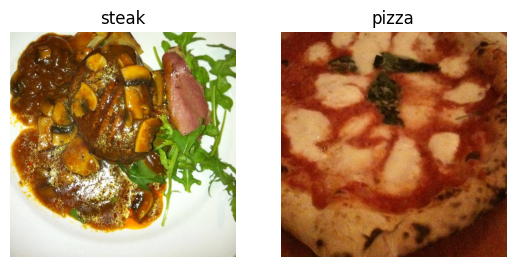

In [102]:
# Visualize data
plt.figure()
plt.subplot(1,2,1)
steak_img = view_random_image("pizza_steak/train","steak")
plt.subplot(1,2,2)
pizza_img = view_random_image("pizza_steak/train","pizza")

<h1 style="color:red">lec 012:-Breaking our CNN model down part 2_ Preparing to load our data.mp4</h1>

### 2. Preprocess the data (prepare it for a model)

In [103]:
# Define directory dataset paths
train_dir = "pizza_steak/train"
test_dir = "pizza_steak/test"


Our next step is to turn our data into **batches**.

A batch is a small subset of data. Rather than look at all ~10,000 images at one time, a model might only look at 32 at a time.

It does this for a couple of reasons:
1. 10,000 images (or more) might not fit into the memory of your processor (GPU).

2. Trying to learn the patterns in 10,000 images in one hit could result in the model not being able to learn very well.

Why 32?

Because 32 is good for your health... (Yann LeCun batch size)

In [104]:
!nvidia-smi

Mon Jan 12 17:10:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             31W /   70W |    1180MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [105]:
# Create train and test data generators and rescale the data
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)


In [106]:
# Load in our image data from directories and turn them into batches
train_data = train_datagen.flow_from_directory(directory=train_dir, # Target directory of images
                                               target_size =(224,224), # Target size of images (height, width)
                                               class_mode="binary", # type of data you're working with
                                               batch_size=32) # size of minibatches to load data into
test_data = test_datagen.flow_from_directory(directory=test_dir,
                                             target_size=(224,224),
                                             class_mode="binary",
                                             batch_size=32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


Because **the channel dimension is inferred automatically from the images**, not something you specify in `target_size`.

---

### What `target_size=(224,224)` means

It controls **only spatial resizing**:

* height = 224
* width = 224

It does **not** define the number of channels.

---

### Where channels come from

`flow_from_directory`:

* Loads images using PIL
* Reads their **color mode**
* Automatically sets channels

Defaults:

* RGB image → `224 × 224 × 3`
* Grayscale image → `224 × 224 × 1`

So internally, the output batch shape becomes:

```
(batch_size, 224, 224, channels)
```

---

### How to control channels (if needed)

You use **`color_mode`**, not `target_size`.

```python
flow_from_directory(
    directory=train_dir,
    target_size=(224,224),
    color_mode="rgb",        # default → 3 channels
    batch_size=32,
    class_mode="binary"
)
```

Or grayscale:

```python
color_mode="grayscale"      # 1 channel
```

---

### Why Keras separates them

* `target_size` → geometric resizing
* `color_mode` → image depth
* Prevents invalid shapes like `(224,224,5)`

---

### One-line summary

You don’t include channels in `target_size` because `flow_from_directory` automatically determines them from `color_mode` and the image files themselves.


In [107]:
# Get a sample of train data batch
images, labels  =next( train_data) # get the "next" batch of images/labels in train_data
len(images), len(labels)

(32, 32)

In [108]:
# How many batches are there?
len(train_data)

47

In [109]:
1500/32

46.875

In [110]:
# Get the first two images
images[:2], images[0].shape

(array([[[[0.56078434, 0.63529414, 0.79215693],
          [0.5647059 , 0.6392157 , 0.7960785 ],
          [0.5647059 , 0.6392157 , 0.80392164],
          ...,
          [0.07843138, 0.08235294, 0.05882353],
          [0.08235294, 0.08235294, 0.07450981],
          [0.09803922, 0.09803922, 0.09803922]],
 
         [[0.5647059 , 0.6392157 , 0.7960785 ],
          [0.5568628 , 0.6313726 , 0.7960785 ],
          [0.5568628 , 0.6313726 , 0.7960785 ],
          ...,
          [0.09803922, 0.10196079, 0.07058824],
          [0.0627451 , 0.06666667, 0.04705883],
          [0.04313726, 0.04313726, 0.03529412]],
 
         [[0.5686275 , 0.6431373 , 0.8078432 ],
          [0.5647059 , 0.6392157 , 0.80392164],
          [0.5647059 , 0.6392157 , 0.8078432 ],
          ...,
          [0.07450981, 0.07843138, 0.04705883],
          [0.15686275, 0.16078432, 0.13725491],
          [0.21568629, 0.21960786, 0.20000002]],
 
         ...,
 
         [[0.3921569 , 0.34901962, 0.22352943],
          [0.39607

In [111]:
# View the first batch of labels
labels

array([0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1.],
      dtype=float32)

<h1 style="color:red">lec 014:-Breaking our CNN model down part 4_ Building a baseline CNN model.mp4</h1>

### 3. Create a CNN model (start with a baseline)

A baseline is a relatively simple model or existing result that you setup when beginning a machine learning experiment and then as you keep experimenting, you try to beat baseline.

> **🔑Note:** In deep learning, there is almost an infinite amount of architectures you can create. So one of the best ways to get started is start with something simple and see if it works on your data and then introduce complexity as required (e.g. look at which current model is performing best in field of your problem).

In [112]:
# Make the creating of our model a little easier
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten , Conv2D, MaxPool2D, Activation
from tensorflow.keras.models import Sequential


In [113]:
# Create the model (this will be our baseline, a layer convolutuonal neural network)
model_4 = Sequential([
    Conv2D(filters=10, # filter is the number of sliding windows going accross an input (higher= more complex model)
           kernel_size=3, # the size of sliding window going across an input
           activation="relu",
           input_shape=(224,224,3), # input layer (specify input shape)
           padding="valid", # if "same", output shape is same as input shape, if "valid", output shape gets compressed
           strides=1), # the size of the step the sliding window takes across an input
    Conv2D(10,3,activation="relu"),
    Flatten(),
    Dense(1,activation="sigmoid") # output layer (working with binary classification so only 1 output neuron)
])

<h1 style="color:red">lec 015:-Breaking our CNN model down part 5_ Looking inside a Conv2D layer.mp4</h1>

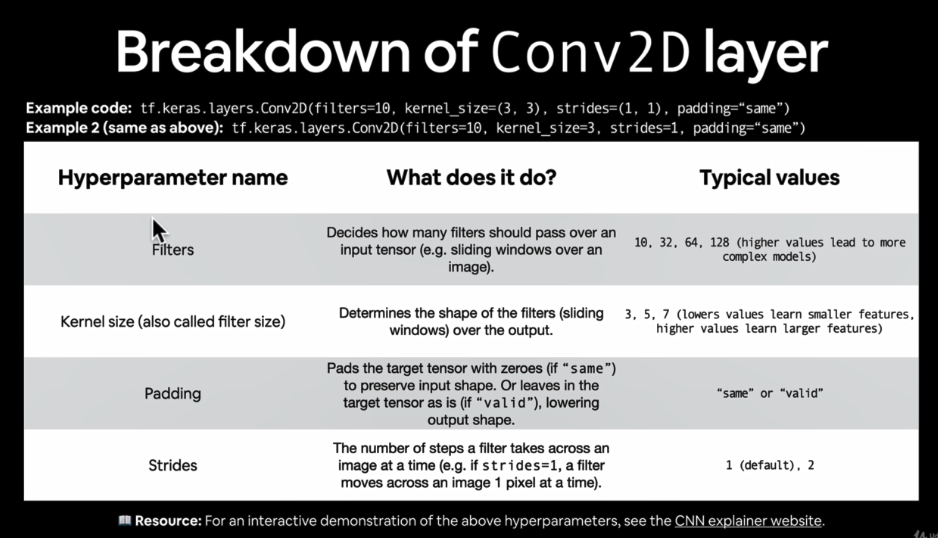

🛠 **Practice:** Understand what's going on in a Conv2D layer by going through the CNN explainer website for 10-20 minutes:
https://poloclub.github.io/cnn-explainer/#article-convolution

<h1 style="color:red">lec 016:-Breaking our CNN model down part 6_ Compiling and fitting our baseline CNN.mp4</h1>

In [114]:
# Compile the model
model_4.compile(loss="binary_crossentropy",
                optimizer = Adam(),
                metrics=["accuracy"])

In [115]:
# Get a summary of our model
model_4.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 484000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │       484,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,191 (1.85 MB)

 Trainable params: 485,191 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Fit the model

In [116]:
# Check the lengths of training and test data generators
len(train_data), len(test_data)

(47, 16)

In [117]:
# Fit the model
history_4 = model_4.fit(train_data, # this is a combination of labels and sample data
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data = test_data,
                        validation_steps = len(test_data)
                        # callbacks=[tensorboard_callback]
)

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 278ms/step - accuracy: 0.5881 - loss: 3.2486 - val_accuracy: 0.8020 - val_loss: 0.4413
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 0.8249 - loss: 0.4129 - val_accuracy: 0.8260 - val_loss: 0.3947
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.9009 - loss: 0.2787 - val_accuracy: 0.8160 - val_loss: 0.3991
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 180ms/step - accuracy: 0.9636 - loss: 0.1347 - val_accuracy: 0.8020 - val_loss: 0.4254
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 231ms/step - accuracy: 0.9956 - loss: 0.0440 - val_accuracy: 0.7920 - val_loss: 0.4953


In [118]:
model_1.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.8647 - loss: 0.3479


[0.3179858922958374, 0.8700000047683716]

<h1 style="color:red">lec 017:-Breaking our CNN model down part 7_ Evaluating our CNN's training curves.mp4</h1>

### 5. Evaluating our model

It looks like our model is learning something, let's evaluate it.

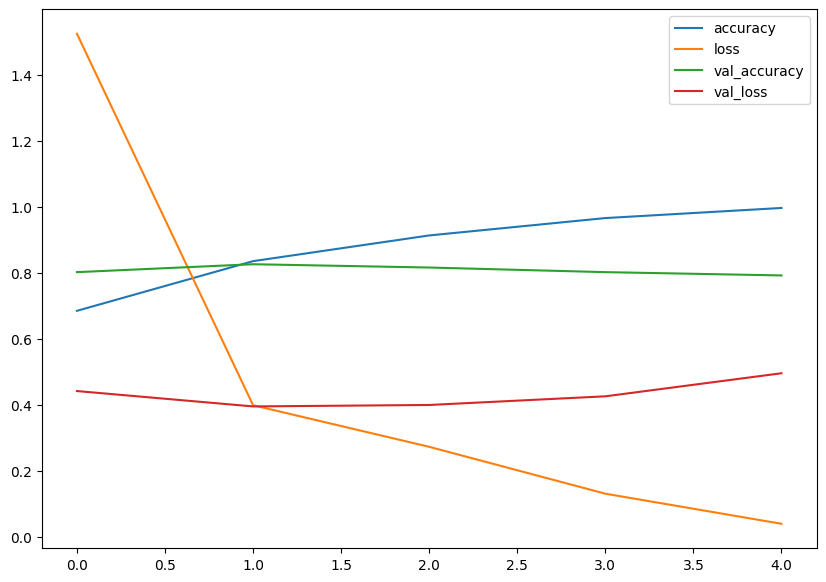

In [119]:
# Let's plot the training curves
import pandas as pd
pd.DataFrame(history_4.history).plot(figsize=(10,7));

In [120]:
# Plot the validation and training curves separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics
  """
  loss = history.history["loss"]
  val_loss = history.history["val_loss"]

  accuracy = history.history["accuracy"]
  val_accuracy = history.history["val_accuracy"]

  epochs = range(len(history.history["loss"]))

  # Plot loss
  plt.plot(epochs,loss,label="training loss")
  plt.plot(epochs,val_loss,label="validation loss")
  plt.title("loss")
  plt.xlabel("epochs")
  plt.legend()

  # Plot accuracy
  plt.figure() # for new figure
  plt.plot(epochs,accuracy,label="training accuracy")
  plt.plot(epochs,val_accuracy,label="validation accuracy")
  plt.title("accuracy")
  plt.xlabel("epochs")
  plt.legend()

> 🔑**Note:** When a model's **validation loss starts to increase** it's likely that the model is **overfitting** the training dataset. This means, it's learning the patterns in the training dataset *too well* and thus the model's ability to generalize to unseen data will be diminished.

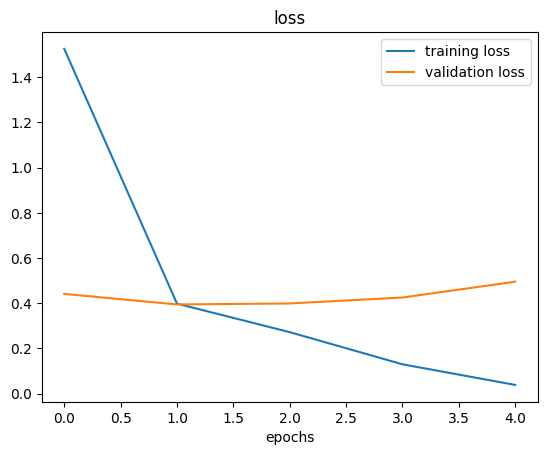

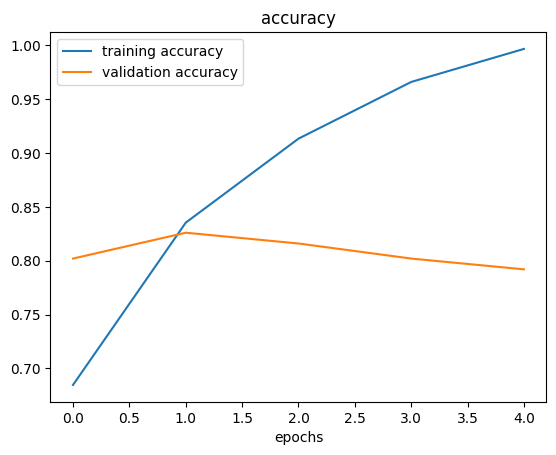

In [121]:
# Check out the loss and accuracy of model_4
plot_loss_curves(history_4)

> 🔑**Note:** Ideally the two loss curves (training and validation) will be very similar to each other (training loss and validation loss decreasing at similar rates), when there are large differences your model may be **overfitting**

<h1 style="color:red">lec 018:-Breaking our CNN model down part 8_ Reducing overfitting with Max Pooling.mp4</h1>

### 6. Adjust the model parameters

Fitting a machine learning model come in 3 steps:

0. Create a baseline
1. Beat the baseline by overfitting a larger model
2. Reduce overfitting

Ways to induce overfitting:

* Increase the number of conv layers
* Increase the number of conv filters
* Add another dense layer to the output of our flattened layer

Reduce overfitting:
* Add data augmentation
* Add regularization layers (such as MaxPool2D)
* Add more data...

> 🔑 **Note:** Reducing overfitting is also known as **regularization**

In [122]:
# Create the model (this is going to be our new baseline)
model_5 = Sequential([
    Conv2D(10,(3,3),activation="relu",input_shape=(224,224,3)),
    MaxPool2D(pool_size=3,padding="valid"),
    Conv2D(10,(3,3),activation="relu"),
    MaxPool2D(),
    Conv2D(10,(3,3),activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1,activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [123]:
# Compile the model
model_5.compile(
    loss="binary_crossentropy",
    optimizer=Adam(),
    metrics=["accuracy"]
)

In [124]:
# Fit the model
history_5 = model_5.fit(train_data,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data),
                        epochs=5
                        )


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 345ms/step - accuracy: 0.6191 - loss: 0.6573 - val_accuracy: 0.7960 - val_loss: 0.4692
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - accuracy: 0.7824 - loss: 0.4849 - val_accuracy: 0.8360 - val_loss: 0.3867
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.7936 - loss: 0.4390 - val_accuracy: 0.8080 - val_loss: 0.4154
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.8213 - loss: 0.4177 - val_accuracy: 0.8600 - val_loss: 0.3528
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 176ms/step - accuracy: 0.8246 - loss: 0.3950 - val_accuracy: 0.8620 - val_loss: 0.3196


In [125]:
# Get a summary of our model with max pooling
model_5.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 74, 74, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 72, 72, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 36, 36, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 34, 34, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 17, 17, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 2890)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │         2,891 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,975 (58.50 KB)

 Trainable params: 4,991 (19.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,984 (39.00 KB)

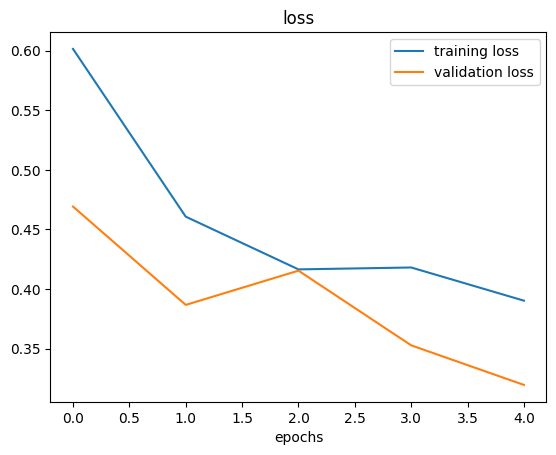

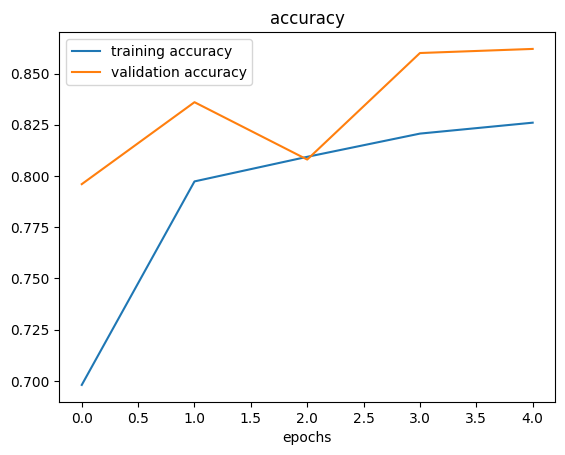

In [126]:
# Plot loss curves
plot_loss_curves(history_5)

<h1 style="color:red">lec 019:-Breaking our CNN model down part 9_ Reducing overfitting with data augmentation.mp4</h1>

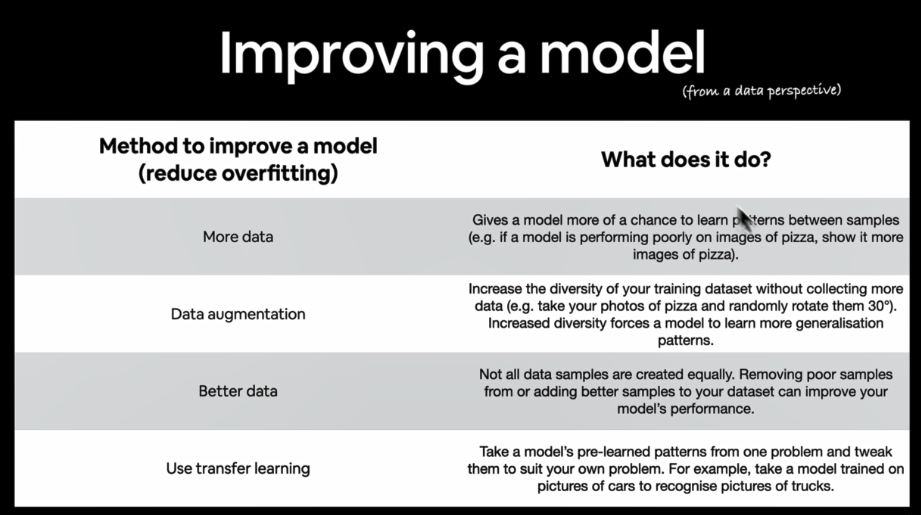

### Opening our bag of tricks and finding data augmentation

In [127]:
# Create ImageDataGenerator training instance with data augmentation
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=0.2, # how much do you want to rotate an image?
                                             shear_range=0.2, # how much do you want to shear an image?
                                             zoom_range=0.2, # zoom in randomly on an image
                                             width_shift_range=0.2, # move your image around on the x-axis
                                             height_shift_range=0.2, # move your image around on the y-axis
                                             horizontal_flip = True) # do you want to flip an image?

# Create ImageDataGenrator without data augmentation
train_datagen = ImageDataGenerator(rescale=1/255.)

# Create ImageDataGenerator without data augmentation for the test dataset
test_datagen = ImageDataGenerator(rescale=1/255.)


> 🤔 **Question:** What is data augmentation?

> Data augmentation is the process of altering our training data, leading it to have more diversity and in turn allowing our models to learn more generalizable (hopefully) patterns.
Altering might mean adjusting the rotation of an image, flipping it, cropping it or something similar.

Let's write some code to visualize data augmentation...

<h1 style="color:red">lec 020:-Breaking our CNN model down part 10_ Visualizing our augmented data.mp4</h1>

In [128]:
# Import data and augment it from training directory
print("Augmented training data")
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(224, 224),
                                                                   batch_size=32,
                                                                   class_mode='binary', # because default is 'categorical'
                                                                   shuffle=False) # for demonstration purposes only
# Create non-augmented train data batches
print("Non-augmented training data")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224,224),
                                               batch_size=32,
                                               class_mode="binary",
                                               shuffle=False)

IMG_SIZE = (224,224)
# Create non-augmented test data batches
print("Non-augmented test data")
test_data = test_datagen.flow_from_directory(test_dir,
                                             class_mode="binary",
                                             target_size=IMG_SIZE,
                                             batch_size=32,)


Augmented training data
Found 1500 images belonging to 2 classes.
Non-augmented training data
Found 1500 images belonging to 2 classes.
Non-augmented test data
Found 500 images belonging to 2 classes.


> 🔑 **Note:** Data augmentation is usually only performed on the training data. Using `ImageDataGenerator` built-in data augmentation parameters our images are left as they are in the directories but are modified as they're loaded into the model.

Finally... let's visualize some augmented data!!!

In [129]:
# Get sample data batches
images,labels = next(train_data)
augmented_images,augmented_labels = next(train_data_augmented) # note: lablels aren't augmented... only data (images)


showing image number: 8


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

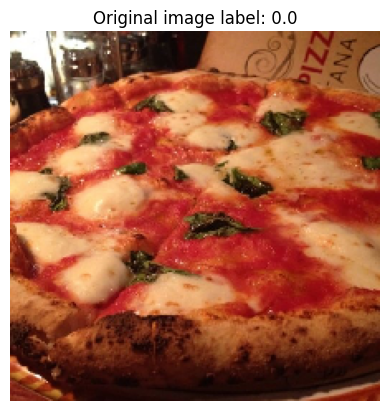

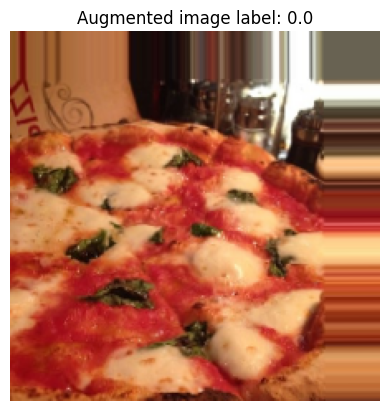

In [130]:
# Show original image and augmented image
import random
random_number = random.randint(0,31) # our batch sizes are 32...
print(f"showing image number: {random_number}")
plt.imshow(images[random_number])
plt.title(f"Original image label: {labels[random_number]}")
plt.axis(False)
plt.figure()
plt.imshow(augmented_images[random_number])
plt.title(f"Augmented image label: {augmented_labels[random_number]}")
plt.axis(False)

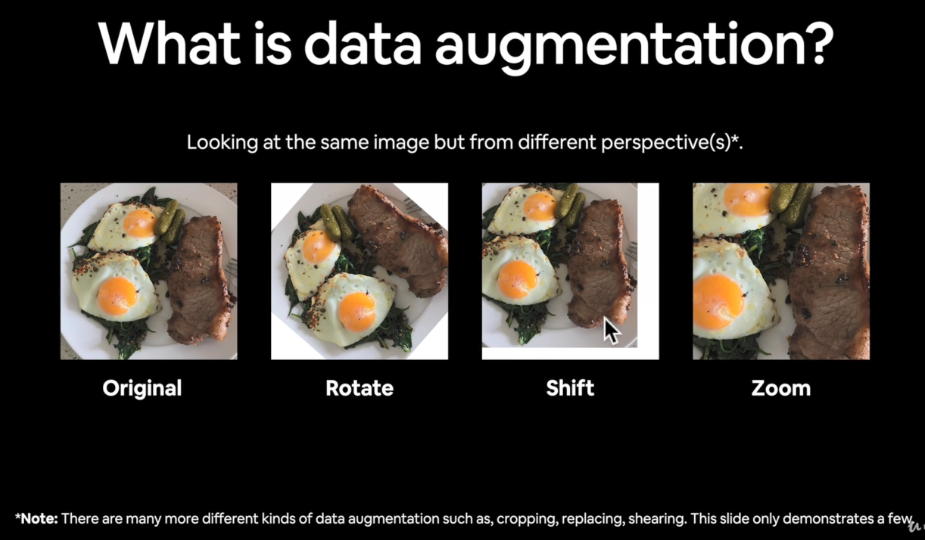

<h1 style="color:red">lec 021:-Breaking our CNN model down part 11_ Training a CNN model on augmented data.mp4</h1>

Now we've seen what augmented data looks like, let's build a model and see how it learns on augmented data.

In [131]:
# Create a model (same as model_5)
model_6 = tf.keras.models.Sequential([
    Conv2D(10,(3,3),activation="relu",input_shape=(224,224,3)),
    MaxPool2D(pool_size=3,padding="valid"),
    Conv2D(10,(3,3),activation="relu"),
    MaxPool2D(),
    Conv2D(10,(3,3),activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1,activation="sigmoid")
])

# Compile the model
model_6.compile(loss="binary_crossentropy",
                optimizer=Adam(),
                metrics=["accuracy"])

# Fit the model
history_6 = model_6.fit(train_data_augmented, # fitting model_6 on augmented training data
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented),
                        validation_data=test_data,
                        validation_steps=len(test_data))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 46s 897ms/step - accuracy: 0.4776 - loss: 0.7351 - val_accuracy: 0.5100 - val_loss: 0.6915
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.5354 - loss: 0.6917 - val_accuracy: 0.5820 - val_loss: 0.6718
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 583ms/step - accuracy: 0.5635 - loss: 0.6860 - val_accuracy: 0.8240 - val_loss: 0.6334
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 480ms/step - accuracy: 0.6740 - loss: 0.6561 - val_accuracy: 0.6680 - val_loss: 0.5834
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 38s 807ms/step - accuracy: 0.6572 - loss: 0.6265 - val_accuracy: 0.8000 - val_loss: 0.5590


here model_6 takes longer time to fit then model_5 because our augmented data is not stored anywhere it augments the data on fly that's why

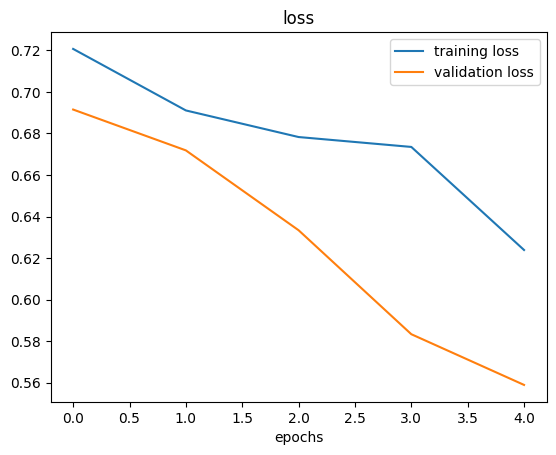

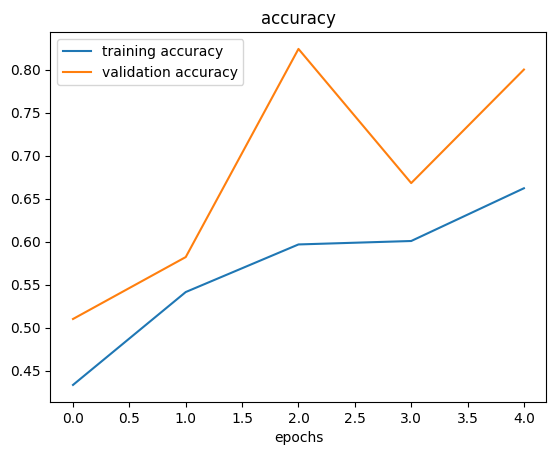

In [132]:
# Check our model's training curves
plot_loss_curves(history_6)

> **Note:** Shuffle is a good thing so don't do `shuffle= False` in `ImageDataGenerator` for our augmented data.

<h1 style="color:red">lec 022:-Breaking our CNN model down part 12_ Discovering the power of shuffling data.mp4</h1>

Let's shuffle our augmented training data and train another model (the same as before) on it and see what happens.

In [133]:
# Import data and augment it and shuffle from training directory
train_data_augmented_shuffled = train_datagen_augmented.flow_from_directory(
    directory=train_dir,
    target_size=(224,224),
    class_mode="binary",
    batch_size=32,
    shuffle=True, # shuffle data this time
)

Found 1500 images belonging to 2 classes.


In [134]:
# Create the model (same as model_5 and model_6)
model_7 = Sequential([
    Conv2D(10,3,activation="relu",input_shape=(224,224,3)),
    MaxPool2D(),
    Conv2D(10,3,activation="relu"),
    MaxPool2D(),
    Conv2D(10,3,activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(1,activation="sigmoid")
])

# Compile the model
model_7.compile(loss="binary_crossentropy",
                optimizer = Adam(),
                metrics=["accuracy"])

# Fit the model
history_7=model_7.fit(train_data_augmented_shuffled, # we're fitting on augmented and shuffled data now
            epochs=5,
            steps_per_epoch=len(train_data_augmented_shuffled),
            validation_data=test_data,
            validation_steps=len(test_data))


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 33s 574ms/step - accuracy: 0.5821 - loss: 0.6739 - val_accuracy: 0.7940 - val_loss: 0.5050
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 31s 661ms/step - accuracy: 0.7304 - loss: 0.5583 - val_accuracy: 0.8020 - val_loss: 0.4481
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 33s 484ms/step - accuracy: 0.7586 - loss: 0.5230 - val_accuracy: 0.8300 - val_loss: 0.4018
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 467ms/step - accuracy: 0.7750 - loss: 0.5014 - val_accuracy: 0.8380 - val_loss: 0.3910
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 557ms/step - accuracy: 0.7584 - loss: 0.5058 - val_accuracy: 0.8240 - val_loss: 0.3769


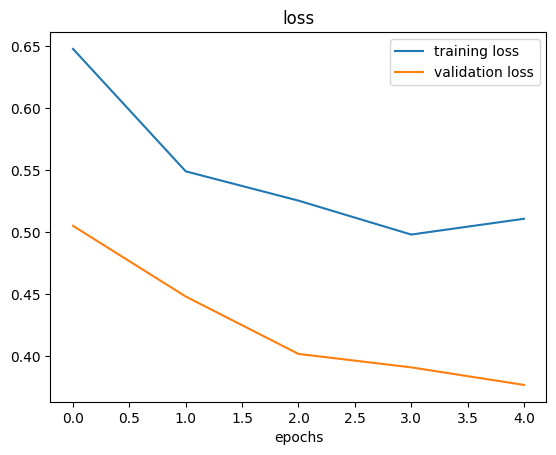

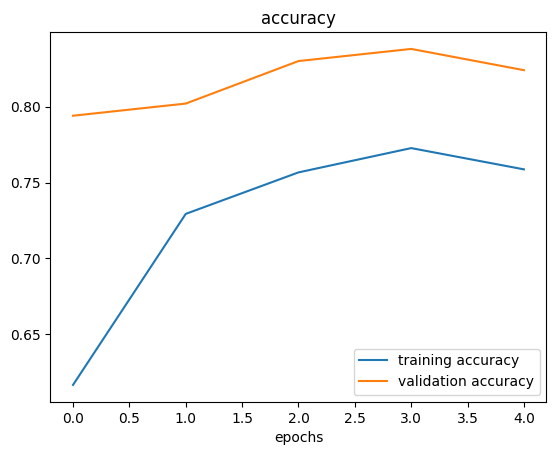

In [135]:
# Plot loss curves
plot_loss_curves(history_7)

> 🔑**Note:** When shuffling training data, the model gets exposed to all different kinds of data during training, thus enabling it to learn features accross a wide array of images (in our case, pizza & steak at the same time instead of just pizza then steak).

<h1 style="color:red">lec 023:-Breaking our CNN model down part 13_ Exploring options to improve our model.mp4</h1>

### 7. Repeat until satisfied

Since we've already beaten our baseline, there are a few things we could try to continue to improve our model:

* Increase the number of model layers (e.g. add more `Conv2D`/`MaxPool2D` layers)
* Increase the number of filers in each convolutional layer (e.g. from 10 to 32 or even 64)
* Train for longer (more epochs)
* Find an ideal learning rate
* Get more data (give the model more opportunities to learn)
* Use **transfer learning** to leverage what another image model has learn and adjust it for our own use case

> 🛠 **Practice:** Recreate the model on the CNN explainer website (same as `model_1`) and see how it performs on the augmented shuffled training data.

<h1 style="color:red">lec 024:-Downloading a custom image to make predictions on.mp4</h1>

## Making a prediction with our trained model on our own custom data

In [136]:
# Classes we're working with
print(class_names)

['pizza' 'steak']


--2026-01-12 17:17:51--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1978213 (1.9M) [image/jpeg]
Saving to: ‘/content/03-steak.jpeg’

/content/03-steak.j 100%[===================>]   1.89M  --.-KB/s    in 0.04s   

2026-01-12 17:17:52 (45.8 MB/s) - ‘/content/03-steak.jpeg’ saved [1978213/1978213]



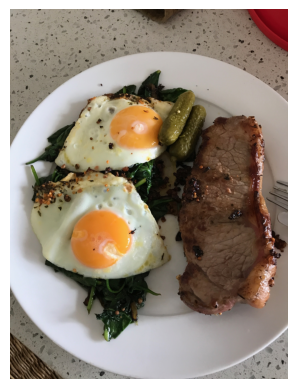

In [137]:
# View our example image
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

!wget -O /content/03-steak.jpeg https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
steak = mpimg.imread("/content/03-steak.jpeg")
plt.imshow(steak)
plt.axis(False)
plt.show()


>**Note:** for converting normal files to raw files rename github.com to raw.githubusercontent.com in github links also remove **\blob** too.

In [138]:
# Check the shape of our image
steak.shape

(4032, 3024, 3)

<h1 style="color:red">lec 025:-Writing a helper function to load and preprocessing custom images.mp4</h1>

> 🔑 **Note:** When you train a neural network and you want to make a prediction with it on your own custom data, it's important that your custom data (or new data) is preprocessed into the same format as the data your model was trained on.

In [139]:
print(tf.expand_dims(steak,axis=0).shape)

(1, 4032, 3024, 3)


In [140]:
expanded_steak = tf.expand_dims(steak,axis=0) # now we have that batch dimension we need to pass this image in our model

In [141]:
# Create a function to import an image and resize it to be able to used with our model
def load_and_prep_image(filename,img_shape=224):
  """
  Reads an image from filename, turns it into a tensor and
  reshape it to (img_shape, img_shape, color_channels).
  """
  # Read in the image
  img = tf.io.read_file(filename)
  # Decode the read file into a tensor
  img = tf.image.decode_image(img)
  # Resize the image
  img = tf.image.resize(img,size=[img_shape,img_shape])
  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [142]:
# Load in and preprocess our custom image
steak = load_and_prep_image("/content/03-steak.jpeg")

In [143]:
# expand the dims (because of batch) and predict label of our custom image
pred=model_7.predict(tf.expand_dims(steak,axis=0))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step


<h1 style="color:red">lec 026:-Making a prediction on a custom image with our trained CNN.mp4</h1>

Looks like our custom image is being put through our model, however, it currently outputs a prediction probability, wouldn't it be nice if we could visualize the image as well as the model's prediction?

In [144]:
# Remind ourselves of our class names
class_names

array(['pizza', 'steak'], dtype='<U5')

In [145]:
# We can index the predicted class by rounding the prediction probability and indexing it on the class names
pred_class = class_names[int(tf.round(pred))]
pred_class

np.str_('steak')

In [146]:
def pred_and_plot(model,filename,class_names=class_names):
  """
  Imports an image located at filename, makes a prediction with
  model and plots the image with the predicted class as the title.
  """
  # Import the  target image and preprocess it
  img = load_and_prep_image(filename)

  # Make a prediction
  pred = model.predict(tf.expand_dims(img,axis=0))

  # Get the predicted class
  pred_class = class_names[int(tf.round(pred))]

  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


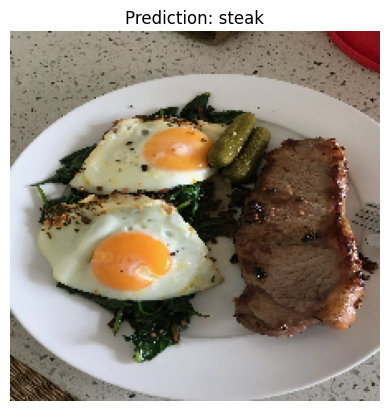

In [147]:
# Test our model on a custom image
pred_and_plot(model_7,"03-steak.jpeg")

Our model works! Let's try it on another image... this time pizza 🍕

--2026-01-12 17:17:55--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2874848 (2.7M) [image/jpeg]
Saving to: ‘03-pizza-dad.jpeg.1’

03-pizza-dad.jpeg.1 100%[===================>]   2.74M  --.-KB/s    in 0.04s   

2026-01-12 17:17:55 (68.8 MB/s) - ‘03-pizza-dad.jpeg.1’ saved [2874848/2874848]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


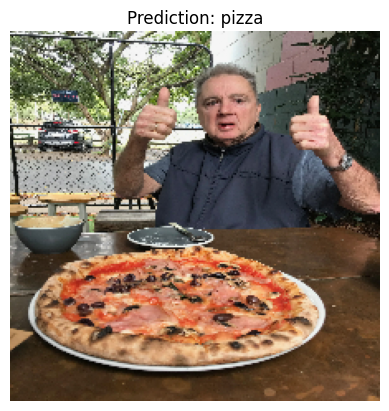

In [148]:
# Download another test custom image and make a prediction on it
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg

pred_and_plot(model_7,"03-pizza-dad.jpeg")

<h1 style="color:red">lec 027:-Multi-class CNN's part 1_ Becoming one with the data.mp4</h1>

# Multi-class Image Classification

We've just been through a bunch of the following steps with a binary classification problem (pizza vs. steak), now we're going to step things up a notch with 10 classes of food(multi-class classification).

1. Become one with the data
2. Preprocess the data (get it ready for a model)
3. Create a model (start with a baseline)
4. Fit the model (overfit it to make sure it works)
5. Evaluate the model
6. Adjust different hyperparameters and improve the model (try to beat baseline/reduce overfitting)
7. Repeat until satisfied


## 1. Import and become one with data

In [149]:
import zipfile
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

# Unzip our data
zip_ref = zipfile.ZipFile("10_food_classes_all_data.zip")
zip_ref.extractall()
zip_ref.close()

--2026-01-12 17:17:56--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.2.207, 74.125.137.207, 142.250.141.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.2.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip.1’

10_food_classes_all 100%[===================>] 495.13M  79.5MB/s    in 5.6s    

2026-01-12 17:18:01 (88.2 MB/s) - ‘10_food_classes_all_data.zip.1’ saved [519183241/519183241]



In [150]:
import os

# Walk through 10 classes of food image data
for dirpath, dirnames, filenames in os.walk("10_food_classes_all_data"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in '10_food_classes_all_data'.
There are 10 directories and 0 images in '10_food_classes_all_data/test'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/hamburger'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/sushi'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/grilled_salmon'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/chicken_curry'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/steak'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/chicken_wings'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/ice_cream'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/ramen'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/pizza'.
There are 0 directories and 250 images in '10_food_classes_all_data/test/fried_rice'.
There are 

In [151]:
# Setup the train and test directories
train_dir = "10_food_classes_all_data/train"
test_dir = "10_food_classes_all_data/test"

In [152]:
# Let's get the class names
import pathlib
import numpy as np
data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


['1684438.jpg']
Image shape: (512, 512, 3)


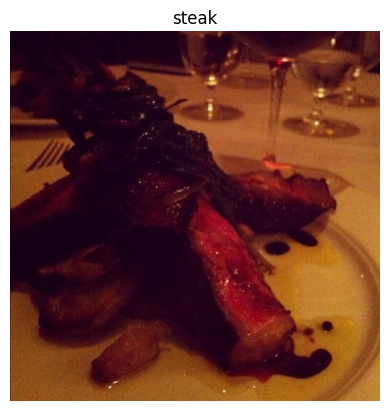

In [153]:
# Visualize, visualize, visualize
import random
img = view_random_image(target_dir=train_dir,
                        target_class=random.choice(class_names))

In [154]:
import random
random.choice(class_names)

np.str_('ramen')

<h1 style="color:red">lec 028:-Multi-class CNN's part 2_ Preparing our data (turning it into tensors).mp4</h1>

### 2. Preprocess the data (prepare it for a model)

In [155]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rescale
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

# Load data in from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224,224),
                                               class_mode="categorical",
                                               batch_size=32,
                                               )

test_data = test_datagen.flow_from_directory(test_dir,
                                             batch_size=32,
                                             target_size=(224,224),
                                             class_mode="categorical")

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


<h1 style="color:red">lec 029:-Multi-class CNN's part 3_ Building a multi-class CNN model.mp4</h1>

<hr>

### 3. Create a model (start with a baseline)

We've been talking a lot about the [CNN explainer website](https://poloclub.github.io/cnn-explainer/#article-convolution)... how about we just take their model (also on 10 classes)  and use it for our problem...?

In [156]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten , Dense, Activation

# Create our model (very similar to previous models but actually the same as CNN explainer website)
model_8 = Sequential([
    Conv2D(10,(3,3),input_shape=(224,224,3)),
    Activation(activation="relu"),
    Conv2D(10,(3,3),activation="relu"),
    MaxPool2D(),
    Conv2D(10,3,activation="relu"),
    Conv2D(10,3,activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(10,activation="softmax")
])

# Compile the model
model_8.compile(loss="categorical_crossentropy",
                optimizer= tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

<h1 style="color:red">lec 030:-Multi-class CNN's part 4_ Fitting a multi-class CNN model to the data.mp4</h1>

In [157]:
# Fit the model
history_8 = model_8.fit(train_data,
                        epochs=5,
                        steps_per_epoch = len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 46s 172ms/step - accuracy: 0.1872 - loss: 2.2358 - val_accuracy: 0.3168 - val_loss: 1.9232
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 72s 142ms/step - accuracy: 0.3701 - loss: 1.8399 - val_accuracy: 0.3496 - val_loss: 1.8397
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 130ms/step - accuracy: 0.4888 - loss: 1.5357 - val_accuracy: 0.3524 - val_loss: 1.8888
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 46s 152ms/step - accuracy: 0.6656 - loss: 1.0357 - val_accuracy: 0.3200 - val_loss: 2.2025
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 47s 176ms/step - accuracy: 0.8561 - loss: 0.4782 - val_accuracy: 0.3116 - val_loss: 3.0435


<h1 style="color:red">lec 031:-Multi-class CNN's part 5_ Evaluating our multi-class CNN model.mp4</h1>

### 5. Evaluate the model

In [158]:
# Evaluate on the test data
model_8.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.3192 - loss: 2.9907


[3.0434701442718506, 0.311599999666214]

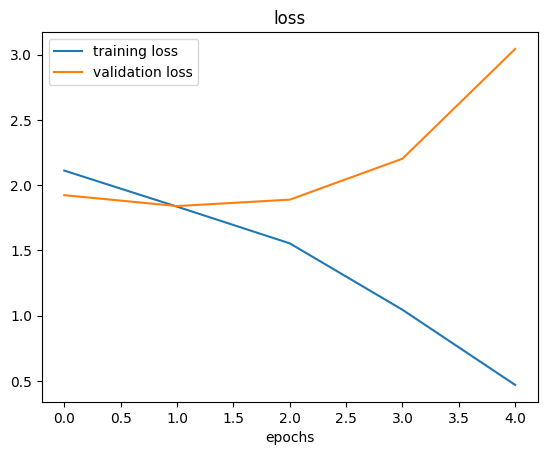

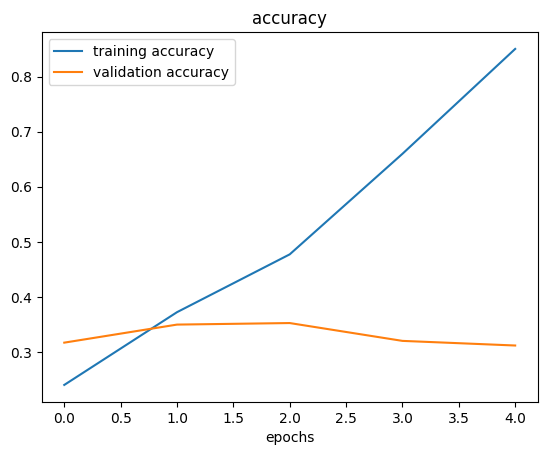

In [159]:
# Check out the model's loss curves on the 10 classes
plot_loss_curves(history_8)

What do these loss curves tell us?

Well... it seems our model is **overfitting** the training set quite badly... in other words, it's getting great results on the training data but fails to generalize well to unseen data and perform poorly on test datasets.

<h1 style="color:red">lec 032:-Multi-class CNN's part 6_ Trying to fix overfitting by removing layers.mp4</h1>

### 6. Adjust the model hyperparameters (to beat the baseline/reduce overfitting)

Due to its performance on the training data, it's clear our model is learning something...

However, it's not generalizing well to unseen data (overfitting).

So, let's try and fix overfitting by...

* **Get more data** - having more data gives a model more oppurtunity to learn diverse patterns...

* **Simplify the model** - if our current model is overfitting the data, it may be too complicated of a model, one way to simplify a model is to: reduce # of layers or reduce # hidden units in layers

* **Use data augmentation** - data augmentation manipulates the training data in such a way to add more diversity to it (without altering the original data)

* **Use transfer learning** - transfer learning leverages the patterns another model has learned on similar data to your own and allows you to use those patterns in your own dataset

In [166]:
# How about we try and simplify the model first?
# Let's try to remove 2 convolutional layers...
model_9 = Sequential([
    Conv2D(10,3,activation="relu",input_shape=(224,224,3)),
    MaxPool2D(),
    Conv2D(10,3,activation="relu"),
    MaxPool2D(),
    Flatten(),
    Dense(10,activation="softmax")
])

model_9.compile(loss="categorical_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [167]:
# To check our previous model so we can simplify it
#model_8.summary()

# model_9 summary
model_9.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 29160)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │       291,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 292,800 (1.12 MB)

 Trainable params: 292,800 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

In [168]:
# Fit the model with 2x conv layers removed
history_9 = model_9.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 40s 161ms/step - accuracy: 0.1930 - loss: 2.4411 - val_accuracy: 0.3016 - val_loss: 1.9601
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 110ms/step - accuracy: 0.3880 - loss: 1.8010 - val_accuracy: 0.3536 - val_loss: 1.8468
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 176ms/step - accuracy: 0.4905 - loss: 1.5479 - val_accuracy: 0.3400 - val_loss: 1.8920
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 33s 142ms/step - accuracy: 0.6253 - loss: 1.1891 - val_accuracy: 0.3284 - val_loss: 2.0435
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 53s 225ms/step - accuracy: 0.7776 - loss: 0.7879 - val_accuracy: 0.3104 - val_loss: 2.4055


we didn't simplify our model that much one reason no. of parameters are still about equal in model_8 and model_9.

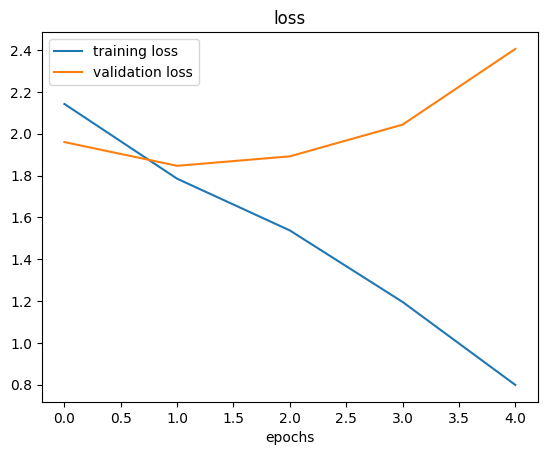

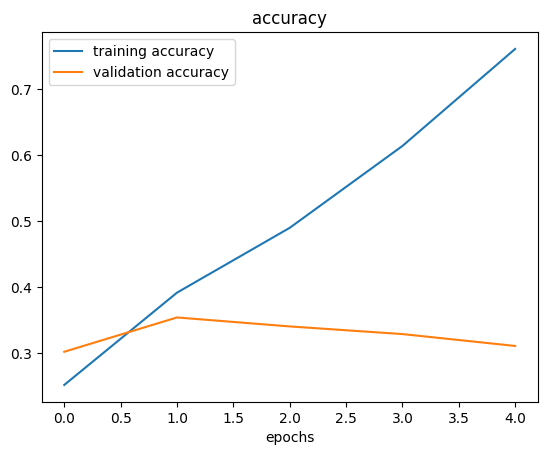

In [169]:
# Check out the loss curves of model
plot_loss_curves(history_9)

Looks like our "simplifying the model" experiment didn't work... the accuracy went down and overfitting continued...

How about we try data augmentation??

<h1 style="color:red">lec 033:-Multi-class CNN's part 7_ Trying to fix overfitting with data augmentation.mp4</h1>

### Trying to reduce overfitting with data augmentation

Let's try and improve our model's results by using augmented training data...

Ideally, we want to:
* Reduce overfitting (get the train and validation loss curves closer)
* Improve validation accuracy

In [170]:
# Create an augmented data generator instance
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             horizontal_flip=True,
                                             zoom_range=0.2,
                                             rotation_range=0.2,
                                             width_shift_range=0.2,
                                             height_shift_range=0.2) # shuffle is true by default


train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(224,224),
                                                                   batch_size=32,
                                                                   class_mode="categorical")

Found 7500 images belonging to 10 classes.


In [171]:
# Let's create another model but this time we'll fit it on the augmented training data of 10 classes
model_10 = tf.keras.models.clone_model(model_8) # cloning model_8

# Compile the cloned model (using the same setup as previous models)
model_10.compile(loss="categorical_crossentropy",
                 optimizer=tf.keras.optimizers.Adam(),
                 metrics=["accuracy"])

In [172]:
model_10.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 222, 222, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │       280,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,920 (1.08 MB)

 Trainable params: 283,920 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [173]:
model_8.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 222, 222, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │       280,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851,762 (3.25 MB)

 Trainable params: 283,920 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 567,842 (2.17 MB)

In [174]:
history_10 = model_10.fit(train_data_augmented,
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented),
                        validation_data=test_data,
                        validation_steps=len(test_data))

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 133s 550ms/step - accuracy: 0.1470 - loss: 2.2503 - val_accuracy: 0.2008 - val_loss: 2.1377
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 174s 741ms/step - accuracy: 0.2559 - loss: 2.0897 - val_accuracy: 0.3168 - val_loss: 1.9670
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 145s 619ms/step - accuracy: 0.2913 - loss: 1.9932 - val_accuracy: 0.3580 - val_loss: 1.8631
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 200s 609ms/step - accuracy: 0.3220 - loss: 1.9356 - val_accuracy: 0.3724 - val_loss: 1.8143
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 196s 583ms/step - accuracy: 0.3346 - loss: 1.9134 - val_accuracy: 0.3700 - val_loss: 1.8025


In [175]:
model_10.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.3750 - loss: 1.7937


[1.802484393119812, 0.3700000047683716]

In [176]:
model_8.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.3122 - loss: 3.0596


[3.0434699058532715, 0.311599999666214]

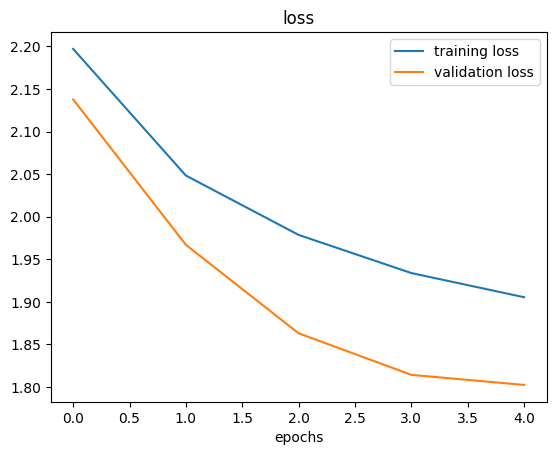

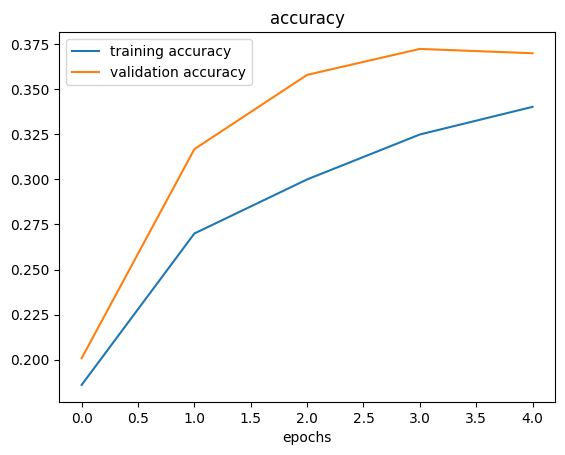

In [177]:
# Check out our model trained on augmented data's loss curves
plot_loss_curves(history_10) # better than model_8 atleast val_accuracy following train_accuracy

Woah! That looks much better, the loss curves are much closer to each other than the baseline model and they look like they're heading in the right direction (certainly not the wrong direction) if we were to train for longer, we might see further improvements.

<h1 style="color:red">lec 034:-Multi-class CNN's part 8_ Things you could do to improve your CNN model.mp4</h1>

### 7. Repeat until satisfied

We could keep going here... continually trying to bring our loss curves closer together and trying to improve the validation/test accuracy.

How?

By running lots of experiments, namely:
- restructuring our model's architecture (increasing layers/hidden units)
- adjust the learning rate
- try different methods of data augmentation (adjust the hyperparameters in our ImageDataGenerator instance)
- training for longer (e.g 10 epochs instead of 5 epochs)
- try **transfer learning**

<h1 style="color:red">lec 035:-Multi-class CNN's part 9_ Making predictions with our model on custom images.mp4</h1>

### Making a prediction with our trained model

Let's use our trained model to make some prediction on our own custom images!

In [179]:
# Remind ourselves of the classes our model is trained on
class_names

array(['chicken_curry', 'chicken_wings', 'fried_rice', 'grilled_salmon',
       'hamburger', 'ice_cream', 'pizza', 'ramen', 'steak', 'sushi'],
      dtype='<U14')

In [180]:
# Download some custom images
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-hamburger.jpeg
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-simple-convnet.png
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-steak.jpeg
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-sushi.jpeg


--2026-01-12 18:24:07--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-hamburger.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3564285 (3.4M) [image/jpeg]
Saving to: ‘03-hamburger.jpeg’

03-hamburger.jpeg   100%[===================>]   3.40M  16.4MB/s    in 0.2s    

2026-01-12 18:24:07 (16.4 MB/s) - ‘03-hamburger.jpeg’ saved [3564285/3564285]

--2026-01-12 18:24:07--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-pizza-dad.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting

> **Note:-** `CTRL + F` to search contents in google colab

In [185]:
# Reconfig pred_and_plot function to work with multi-class images
def pred_and_plot(model,filename,class_names=class_names):
  """
  Imports an image located at filename, makes a prediction with
  model and plots the image with the predicted class as the title.
  """
  # Import the  target image and preprocess it
  img = load_and_prep_image(filename)

  # Make a prediction
  pred = model.predict(tf.expand_dims(img,axis=0))

  # Add in logic for multi-class & get pred_class name
  if len(pred[0])>1: # pred is 2d array in multi-class so pred[0]
    pred_class = class_names[tf.argmax(pred[0])]
  else:
    pred_class = class_names[int(tf.round(pred))]

  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False);

Looks like our model didn't perform very well on our custom images but this is because it only achieved ~39% accuracy on the test data. So we can expect it to function quite poorly on other unseen data.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


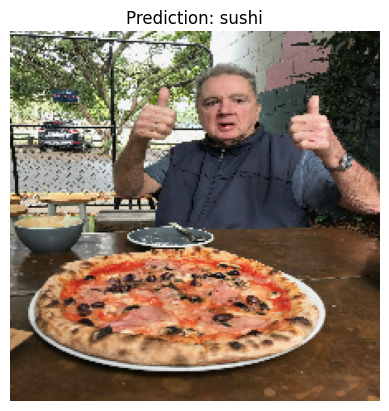

In [187]:
# Make a prediction using model_10
pred_and_plot(model=model_10,
              filename="03-pizza-dad.jpeg",
              class_names=class_names)

<h1 style="color:red">lec 036:-Saving and loading our trained CNN model.mp4</h1>

### Saving and loading our model

In [188]:
# Save a model
model_10.save("saved_trained_model_10.keras")

In [189]:
# Load in a trained model and evaluate it
loaded_model_10 = tf.keras.models.load_model("saved_trained_model_10.keras")
loaded_model_10.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.3616 - loss: 1.8110


[1.8024847507476807, 0.3700000047683716]

In [190]:
# Compare our loaded model to our existing model
model_10.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.3816 - loss: 1.7748


[1.8024847507476807, 0.3700000047683716]

<body>
                <div class="container">
                <div class="row">
                <div class="col-md-10 col-md-offset-1">
                    <p class="lead"><p>Boom boom! You’ve just taught a computer to see the world leveraging the power of Convolutional Neural Networks and TensorFlow!</p><p>These are the same kind of models powering use cases such as Tesla’s self-driving cars.</p><p>How cool is that?</p><p>You also learned how to import and preprocess some of your own custom images to predict on (because after all, that’s what we want to do with our models, use them on data outside of our notebooks).</p><p>Specifically, you should be able to:</p><ul><li><p>Describe different computer vision problems</p></li><li><p>Load and preprocess data for computer vision problems with TensorFlow</p></li><li><p>Build a convolutional neural network with convolutional and max pooling layers for binary and multi-class image classification</p></li><li><p>Save and load trained TensorFlow model</p></li></ul><p>In other words, you learned a whole bunch.</p><p>But before heading on to learn more, you should practice what you’ve learned.</p><p>In the <a href="https://github.com/mrdbourke/tensorflow-deep-learning" rel="noopener noreferrer" target="_blank">course GitHub repo</a> under “Course Materials”, you'll find a series of exercises and extra-curriculum suggestions.</p><p>Going through these will help you understand what’s happening within the Convolutional Neural Networks you’ve built and in turn, will help you build better models in the future.</p><p>See the link below for more.</p><ul><li><p><a href="https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/README.md#-03-computer-vision--convolutional-neural-networks-in-tensorflow-exercises" rel="noopener noreferrer" target="_blank">Computer and Convolutional Neural Networks with TensorFlow Exercises &amp; Extra-curriculum</a></p></li></ul><p>And remember, if you have any questions, be sure to <a href="https://github.com/mrdbourke/tensorflow-deep-learning/discussions" rel="noopener noreferrer" target="_blank">add them to the discussions page</a>.</p><p><strong>Challenge:</strong> What’s a problem you think computer vision could be used for? It could be anything (existing or new)!</p><p>Send a message with your answer(s) to the #machinelearning-datascience channel on Discord and mention my name (@mrdbourke), I’d love to hear them!</p><p>See you in the next module!</p><p>- Daniel</p><p>Web: <a href="http://www.mrdbourke.com/" rel="noopener noreferrer" target="_blank">www.mrdbourke.com</a></p><p>YouTube: <a href="https://dbourke.link/youtube" rel="noopener noreferrer" target="_blank">https://dbourke.link/youtube</a></p></p>
                </div>
                </div>
                </div>
                <script src="https://maxcdn.bootstrapcdn.com/bootstrap/3.3.7/js/bootstrap.min.js" integrity="sha384-Tc5IQib027qvyjSMfHjOMaLkfuWVxZxUPnCJA7l2mCWNIpG9mGCD8wGNIcPD7Txa" crossorigin="anonymous"></script>
                </body>